# Необходимые импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных

In [2]:
data = pd.read_csv("../data/creditcard.csv")

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data[data.isna().sum(axis=1) > 0]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Анализ данных

## Целевая переменная

<Axes: xlabel='Class', ylabel='count'>

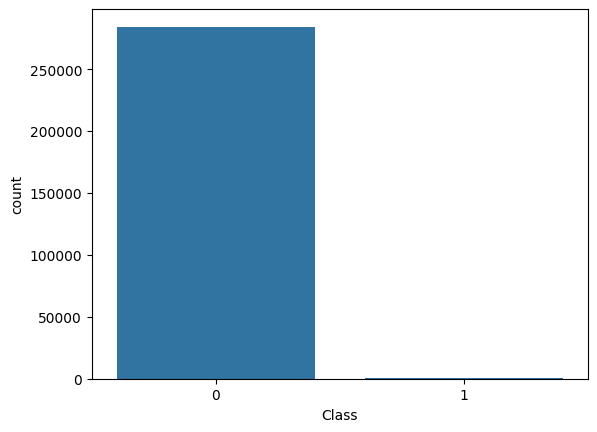

In [6]:
sns.countplot(data=data, x='Class')

In [7]:
data.Class.value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

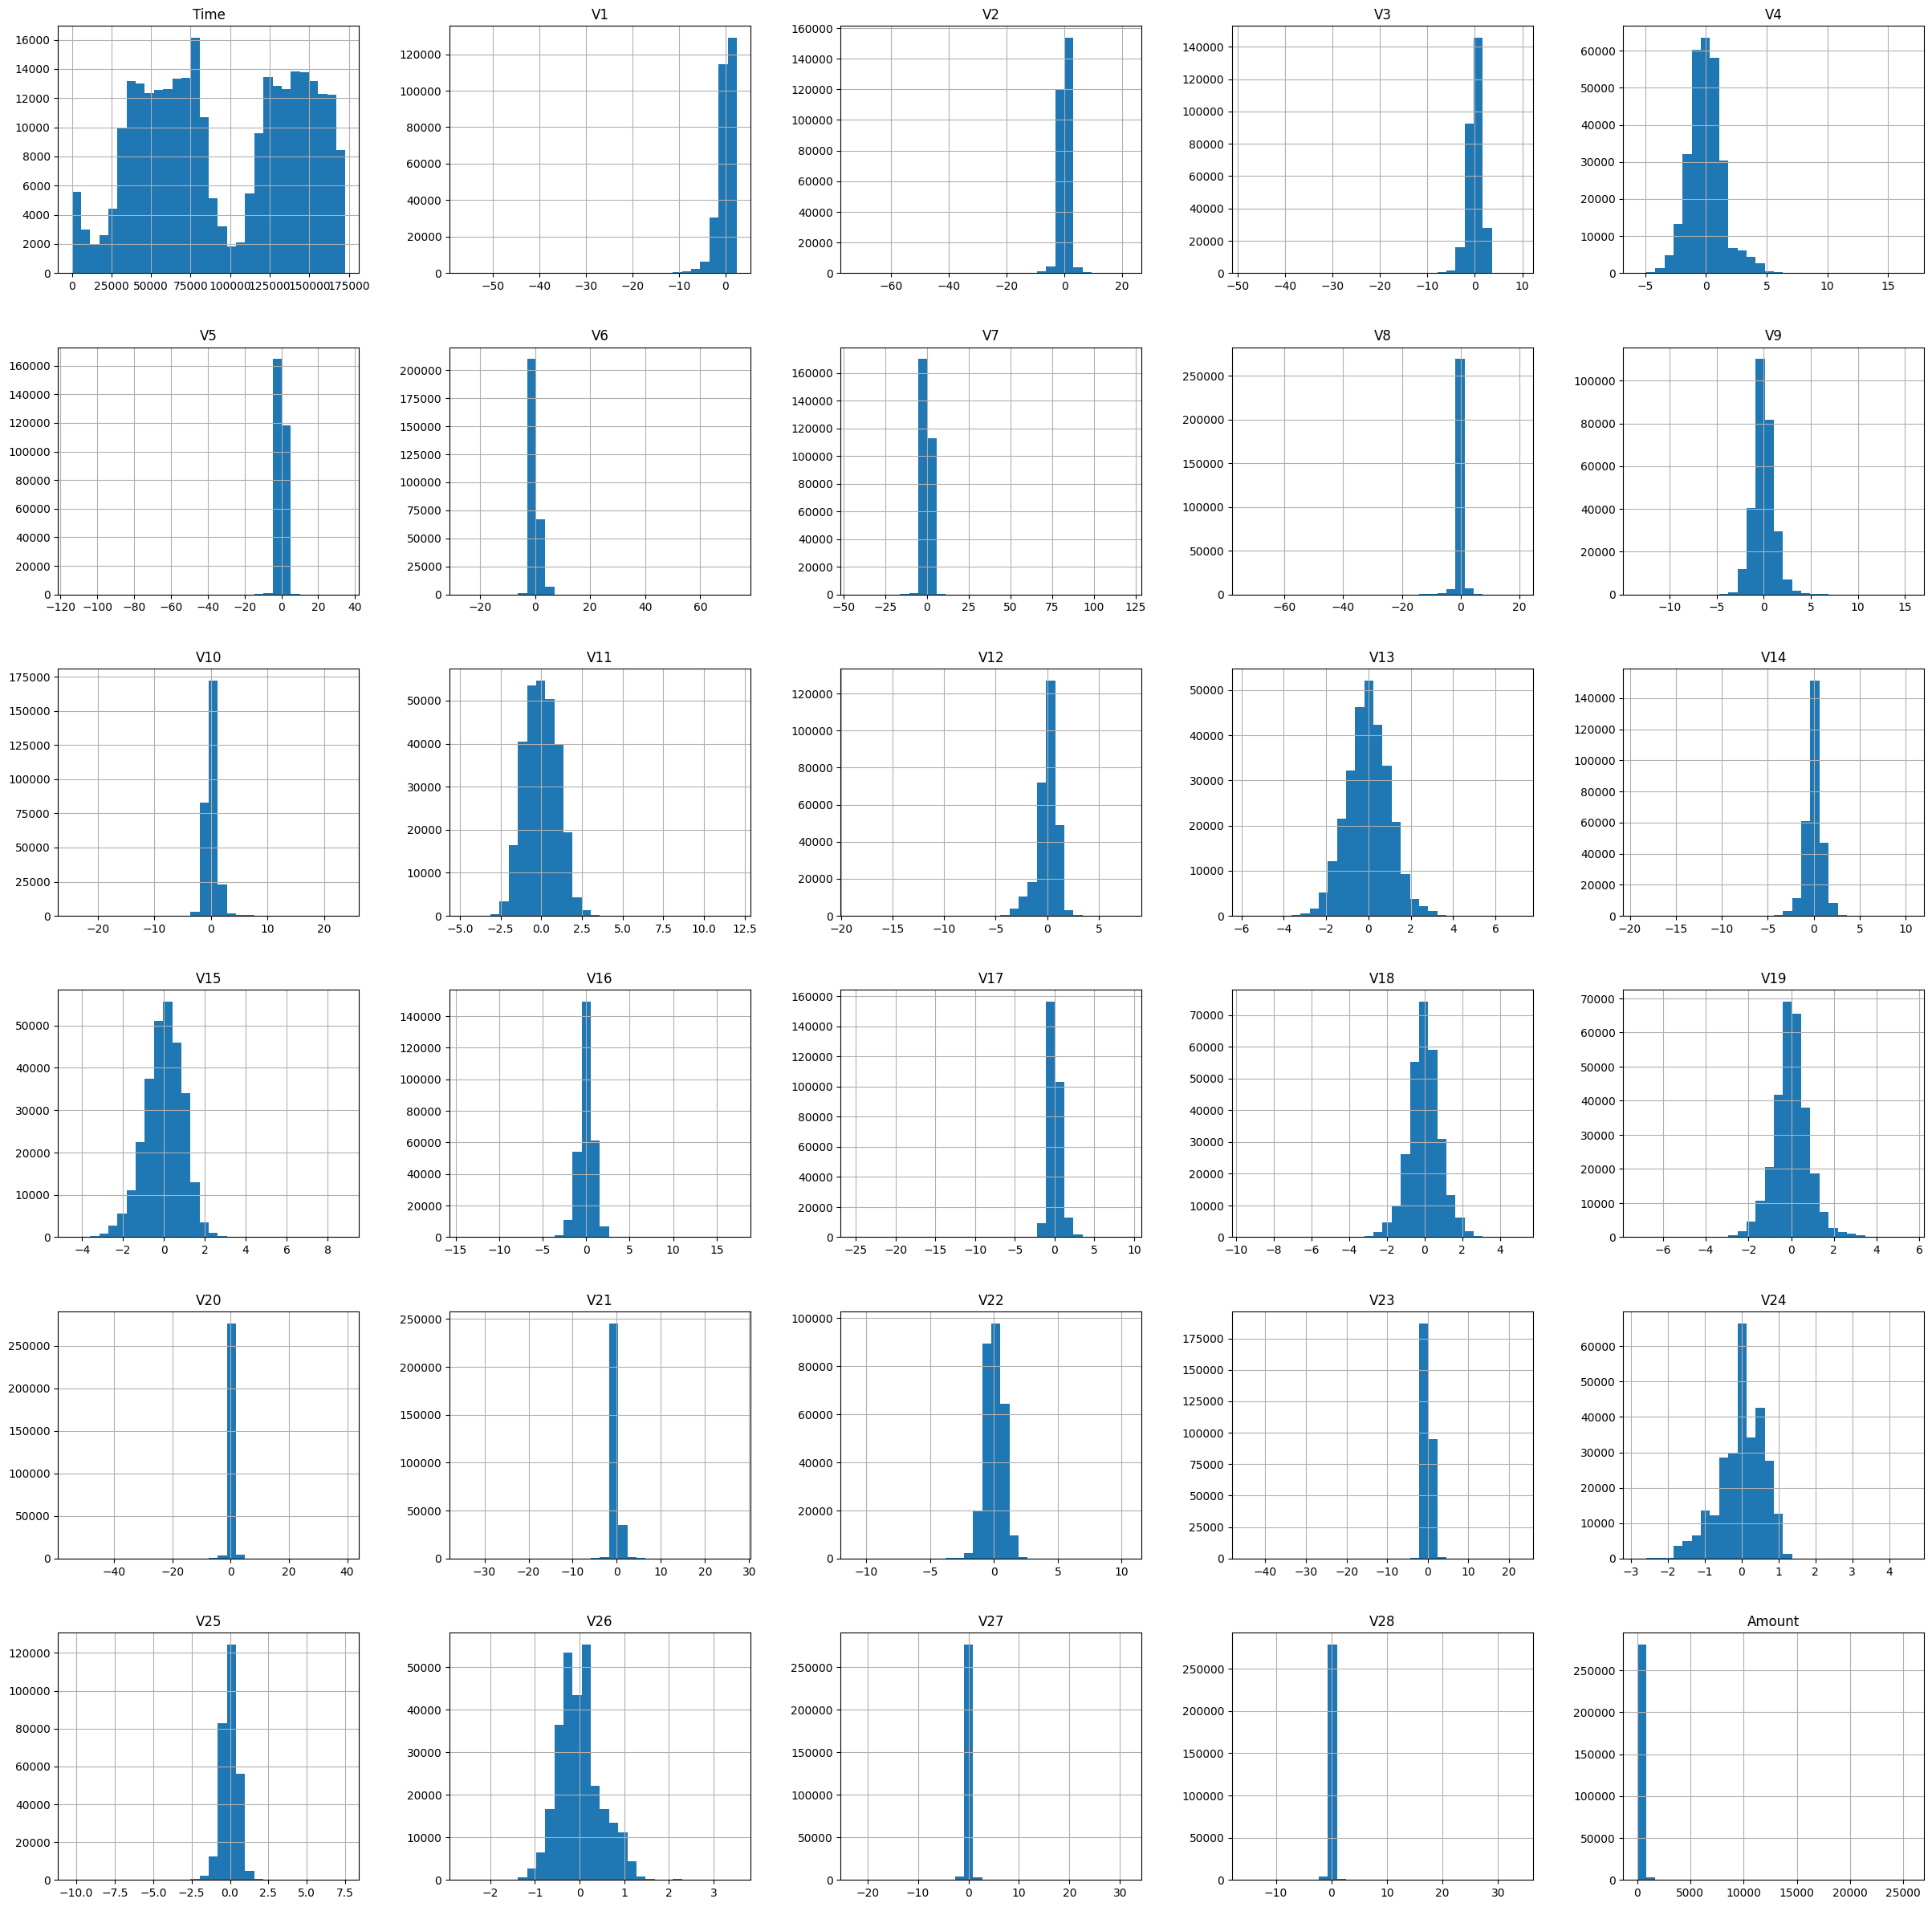

In [8]:
data.drop("Class", axis=1).hist(bins=30, figsize=(30,30));

### Все V фичи распределены вокруг нуля. Некоторые имеют форму распределения похожую на нормальную. Amount сильно дисбалансирована (right-skewed). 

# Карта корреляций

In [9]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler


data['amount_scaled'] = RobustScaler().fit_transform(data[['Amount']])
data['time_scaled'] = MinMaxScaler().fit_transform(data[['Time']])
data.drop(['Time', 'Amount'], axis=1, inplace=True)


<Axes: >

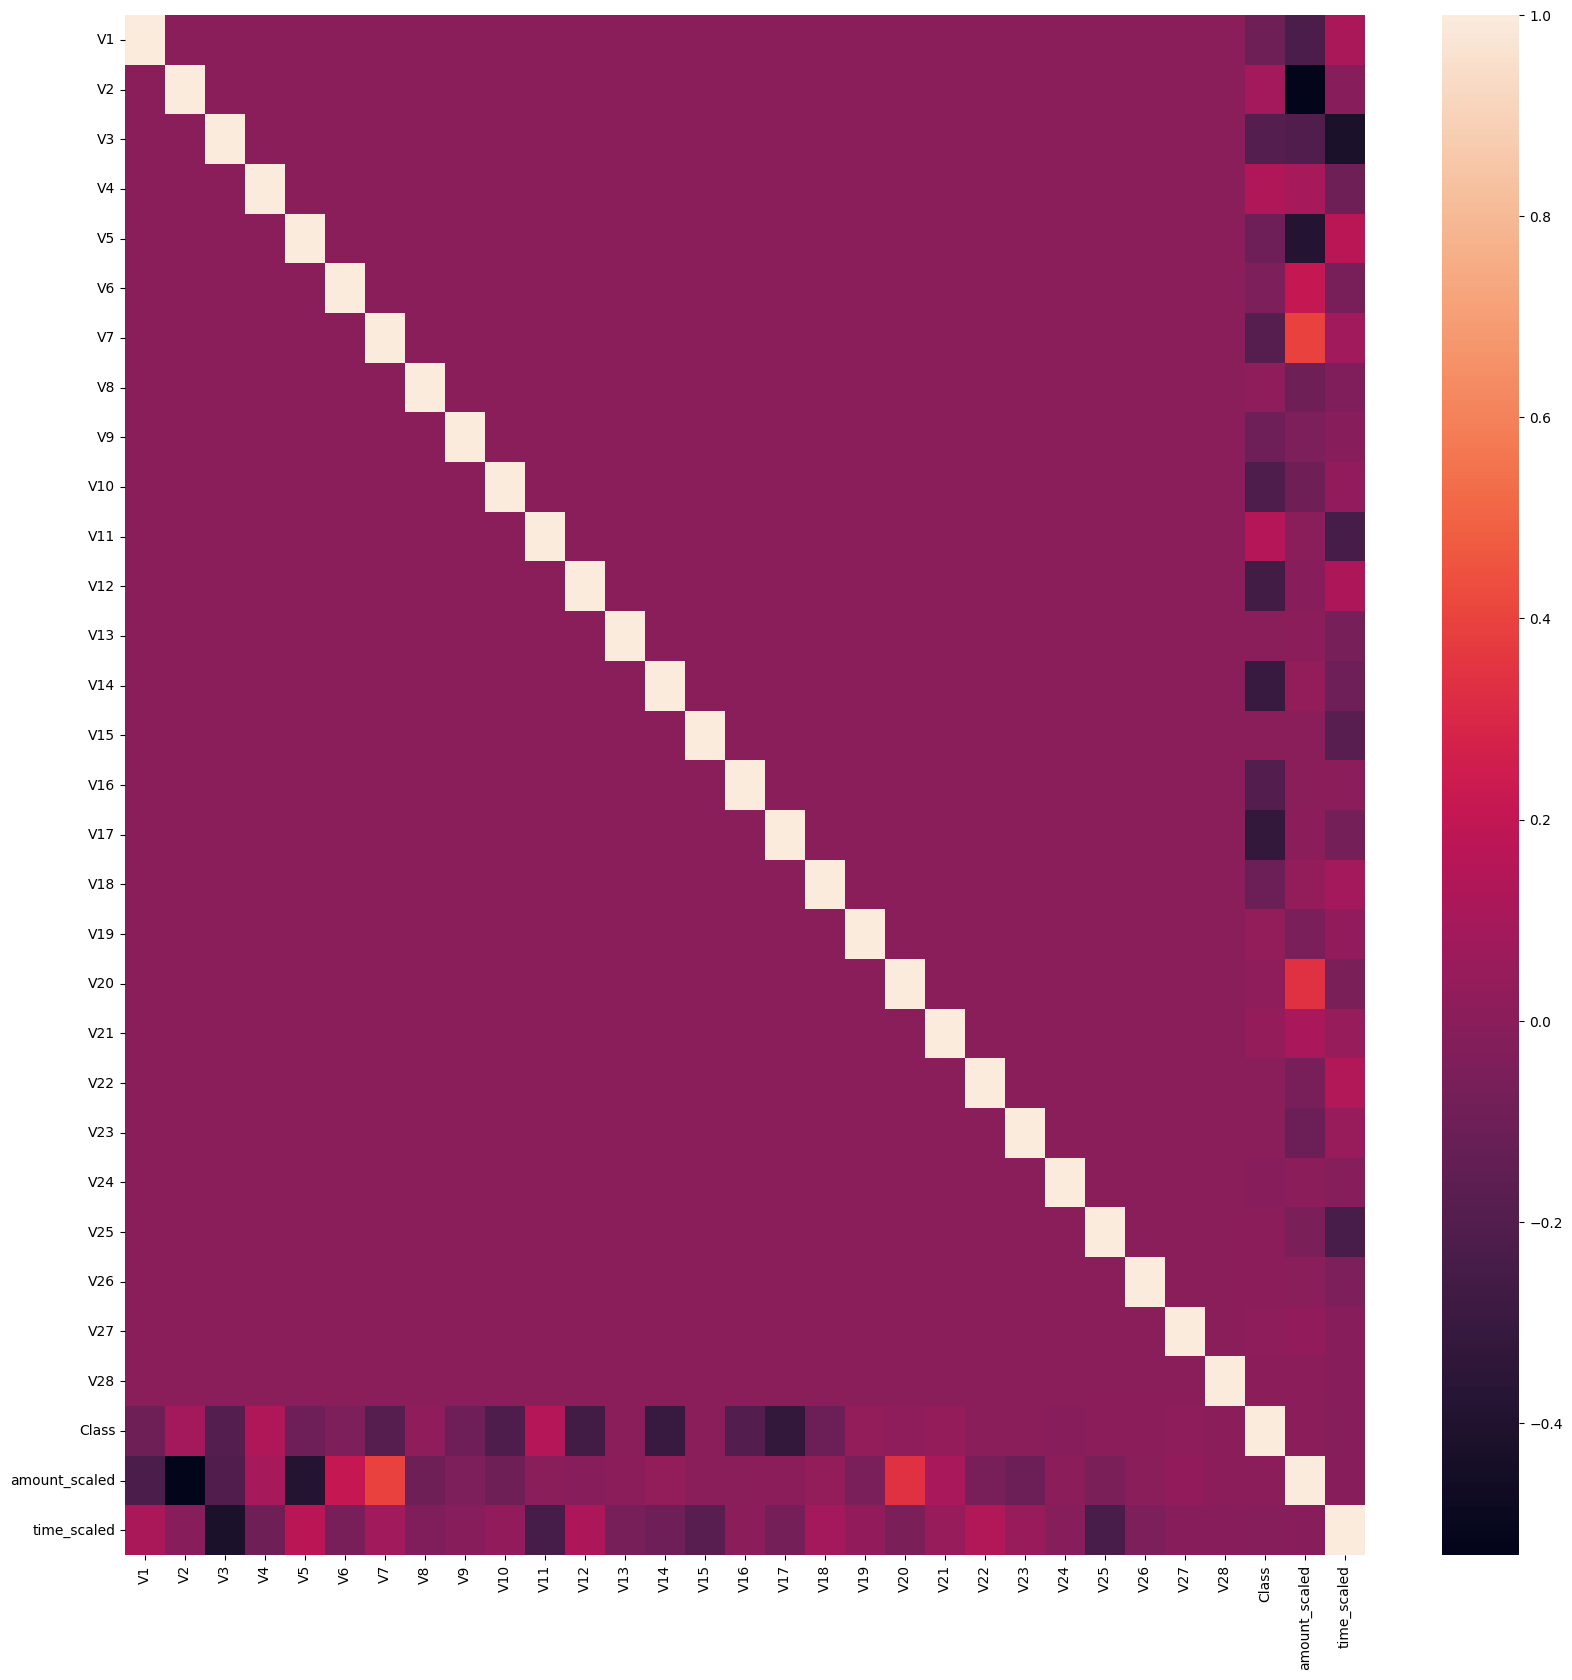

In [10]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr())

In [11]:
data.corr()['Class'].sort_values(ascending=False)[:10]

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

<Axes: title={'center': 'feature correlations with target'}>

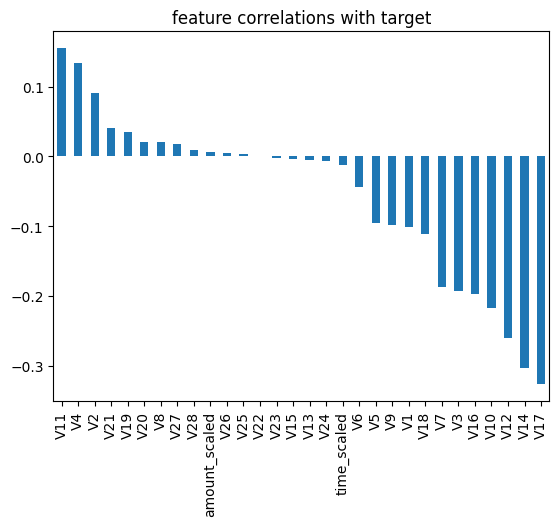

In [12]:
data.corr()['Class'].sort_values(ascending=False)[1:].plot(kind='bar', title='feature correlations with target')

# Исследование фичей

<Axes: xlabel='V17', ylabel='V11'>

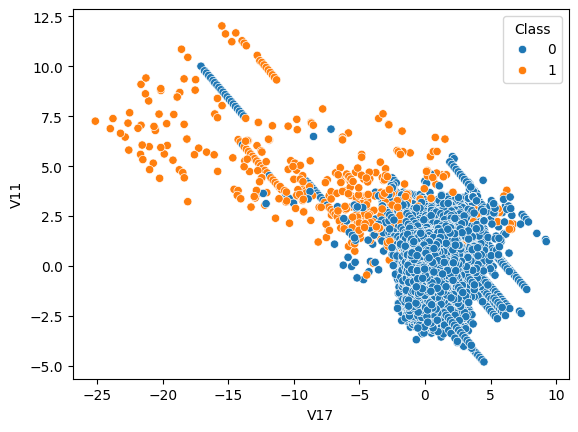

In [13]:
sns.scatterplot(data=data, x='V17', y='V11', hue='Class')

### Наблюдается интересная закономерность: точки относящиеся к классу non-fraud сгруппированы в плотный кластер, в то время как точки класса fraud сосредоточены в гораздо более разреженном кластере. 

<Axes: xlabel='V14', ylabel='V4'>

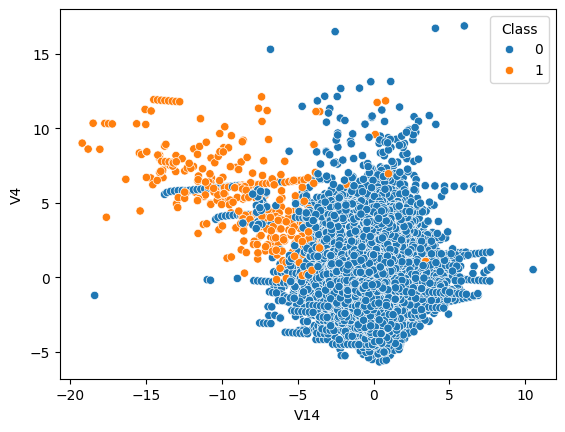

In [14]:
sns.scatterplot(data=data, x='V14', y='V4', hue='Class')

### На самом деле данное поведение наблюдается на всех фичах в датасете. Это связано с тем, что у класса fraud распределение очень отличается от нормального, оно вообще трудно прослеживаемо в силу природы мошеннических операций - мошенники всегда придумывают разные способы обмана, а не следуют одному и тому же паттерну.

# Заключение

 - Данные очень несбалансированны. Класс, несущий интерес для бизнеса, имеет долю лишь 0.17%.
 - С целевой переменной имеют значимую позитивную корреляцию: V11, V4, V2
 - С целевой переменной имеют значимую негативную корреляцию: V17, V14, V12, V10
 - фича amount единственная имеет корреляции с остальными фичами, но она почти никак не скоррелирована с таргетом. 